In [1]:
import logging
logging.basicConfig(level=logging.INFO)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import numericalunits as nu


import wimprates

/home/loren/projects/wimprates/wimprates/utils.py:12: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


------------------------------------------
Migdal ionisation probabilities
P. Cox, M. Dolan, C. McCabe, H. Quiney (2022)
arXiv:2208.12222
------------------------------------------


In [2]:
wimprates.rate_wimp_std(1, mw=50, sigma_nucleon=1e-45, m_med=1e-3)

INFO:wimprates.utils:Result saved to cache: wimprates_cache/rate_wimp_2abbdbc46110094a37224b45f9fcde8bc8f8706b4d6822bef503450f2598e91b.pkl


0.0005039148227443926

In [3]:
wimprates.rate_wimp_std(1, mw=50, sigma_nucleon=1e-45)

INFO:wimprates.utils:Result saved to cache: wimprates_cache/rate_wimp_fb8a0f2883d3c387f8c31f395c2a48e6ed5b7eabcd39e70cdce1d1442fbdbf34.pkl


30.395153947314654

In [4]:
energies = np.linspace(0.01, 40, 100)
dr = wimprates.rate_wimp_std(energies, mw=50, sigma_nucleon=1e-45)

INFO:wimprates.utils:Result saved to cache: wimprates_cache/rate_wimp_cb35ba3c892e55a74662321ad0be2d1ca31e78bbd2c34e70870766ac642acd3a.pkl


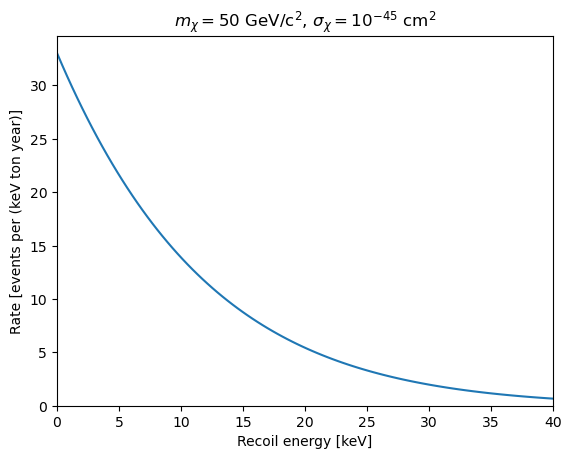

In [5]:
plt.plot(energies, dr)

plt.xlabel("Recoil energy [keV]")
plt.ylabel("Rate [events per (keV ton year)]")
plt.title(r"$m_\chi = 50$ GeV/c${}^2$, $\sigma_\chi = 10^{-45}$ cm${}^2$")
plt.xlim(0, energies.max())
plt.ylim(0, None);

In [6]:
help(wimprates.rate_wimp_std)

Help on function rate_wimp_std in module wimprates.summary:

rate_wimp_std(
    es,
    mw,
    sigma_nucleon,
    m_med=inf,
    t=None,
    halo_model=None,
    **kwargs
)
    Differential rate per (ton year keV) of WIMP-nucleus scattering.
    :param es: Recoil energies in keV
    :param mw: WIMP mass in GeV/c^2
    :param sigma_nucleon: WIMP-nucleon cross-section in cm^2
    :param m_med: Medator mass in GeV/c^2. If not given, assumed very heavy.
    :param t: A J2000.0 timestamp. If not given,
    conservative velocity distribution is used.
    :function halo_model : class (similar to the standard
    halo model) giving velocity distribution and dark matter density
    :returns: numpy array of same length as es

    Further arguments are as for rate_wimp; see docstring of rate_wimp.



In [7]:
help(wimprates.rate_wimp)

Help on function rate_wimp in module wimprates.summary:

rate_wimp(
    es,
    mw,
    sigma_nucleon,
    interaction='SI',
    detection_mechanism='elastic_nr',
    m_med=inf,
    t=None,
    halo_model=None,
    **kwargs
)
    Differential rate per unit time, unit detector mass
    and unit recoil energy of WIMP-nucleus scattering.
    Use numericalunits to get variables in/out in the right units.

    :param es: Energy of recoil (for elastic_nr)
    or emitted photon(for bremsstrahlung and Migdal)
    :param mw: Mass of WIMP
    :param sigma_nucleon: WIMP-nucleon cross-section
    :param interaction: string describing DM-nucleus interaction. Options:
        'SI' for spin-independent scattering;
            equal coupling to protons and neutrons.
        'SD_n_xxx' for spin-dependent scattering
            n can be 'n' or 'p' for neutron or proton coupling (at first order)
            x can be 'central', 'up' or 'down' for
                theoretical uncertainty on structure functi